In [3]:
import statsmodels.api as sm
data = sm.datasets.co2.load().data
data.head()

,co2
1958-03-29,316.1
1958-04-05,317.3
1958-04-12,317.6
1958-04-19,317.5
1958-04-26,316.4


In [5]:
data.shape
data.isnull().sum()

,0
co2,59


<Axes: >

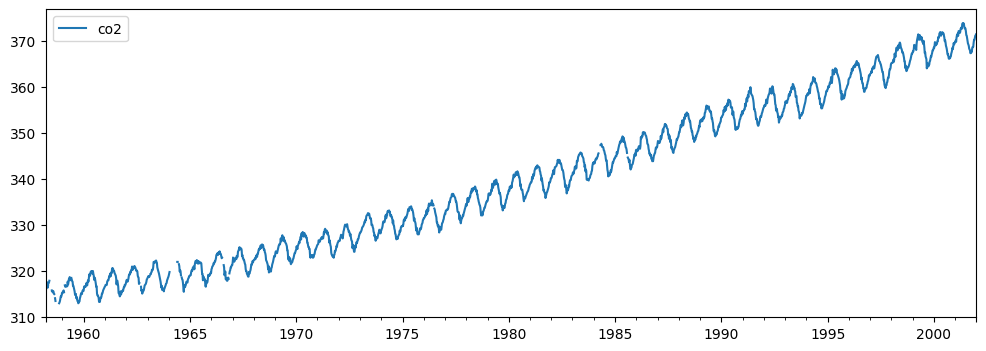

In [6]:
data.plot(figsize=(12,4))

In [7]:
data['co2'] = data['co2'].interpolate()
data.isnull().sum()

,0
co2,0


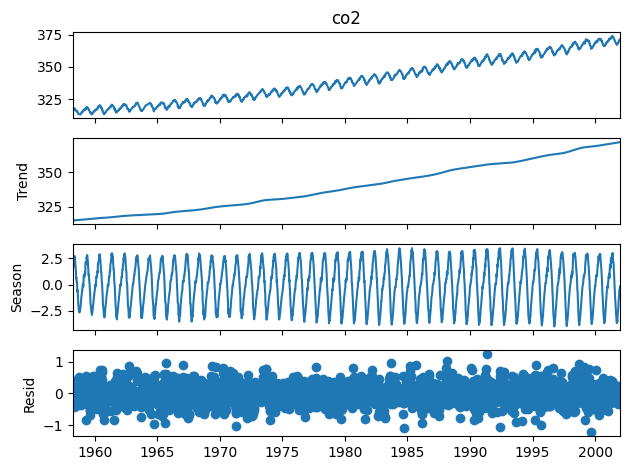

In [8]:
from statsmodels.tsa.seasonal import STL

stl = STL(data['co2'], period=52)  # 52 because it's weekly data (~52 weeks/year)
result = stl.fit()

result.plot();

In [2]:
from statsmodels.tsa.stattools import adfuller
result=adfuller(data['co2'])
print(result[1])

NameError: name 'data' is not defined

<Axes: >

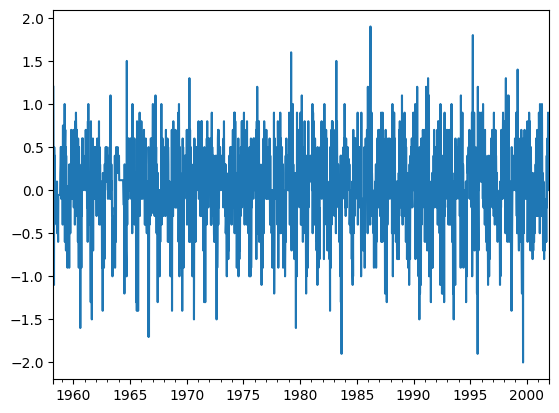

In [13]:
data_diff = data['co2'].diff().dropna()
data_diff.plot()

In [15]:
result_diff = adfuller(data_diff)
print(result_diff[0])
print(result_diff[1])

-15.727522408375835
1.3013480157810805e-28


/tmp/ipykernel_635/3269530353.py:1: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result_diff = adfuller(data_diff)


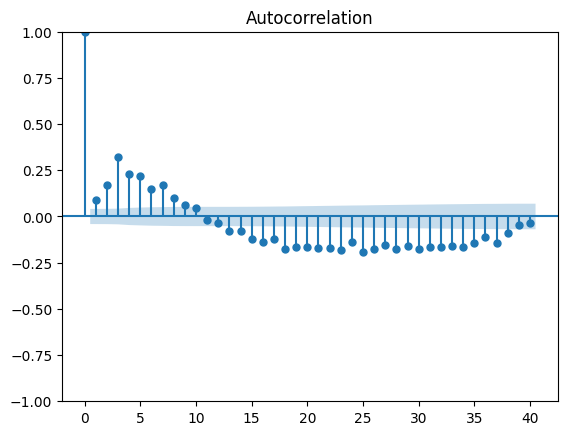

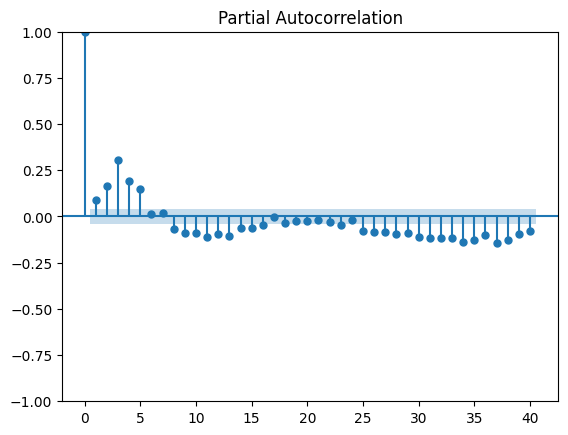

In [18]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(data_diff, lags=40);
plot_pacf(data_diff, lags=40);


In [6]:
train = data['co2'][:-104]
test = data['co2'][-104:]

In [7]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(train, trend ='add', seasonal ='add',seasonal_periods=52).fit()
forecast_hw =model.forecast(len(test))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/holtwinters/model.py:1065: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  res = self._optimize_parameters(res, use_brute, method, minimize_kwargs)


In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

train_monthly = train.resample('M').mean()
test_monthly = test.resample('M').mean()

model = SARIMAX(train_monthly, order=(1,1,1), seasonal_order=(1,1,1,12))
fit = model.fit()

forecast_arima = fit.forecast(len(test_monthly))

/tmp/ipykernel_531/3296449142.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  train_monthly = train.resample('M').mean()
/tmp/ipykernel_531/3296449142.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  test_monthly = test.resample('M').mean()
